# 運動の種類・時間と心拍数：Kaggle公開データ分析

run_id: `v020-exp-17`

## 計画
Kaggle Python SDKのみで公開データを検索・取得し、列定義、標本単位、欠損、重複、意味的異常を先に確認する。反復測定なら個人内比較を主解析とし、横断標本なら交絡を考慮した記述的・関連的比較に限定する。運動種別・時間ごとの平均・分布・差と不確実性を図表化する。欠損処理は観測パターンを見て決定する。感度分析と必要な追加依頼（最大3回）を実施し、全コードセルの上からの再実行後にvisual_audit=Trueで監査する。外部CSVミラー・端末・subprocess・外部スクリプト・エージェントは使用しない。Kaggleトークンは一切保存・表示しない。

In [1]:
from pathlib import Path
import os, sys, json, io, contextlib, hashlib, logging
from datetime import datetime, timezone
from dataclasses import asdict
REPO = Path('/home/nahisaho/GitHub/jupytermind')
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark' / 'projects')
from ai_data_scientist import project_manager, lifecycle, language_router
import nbformat
RUN_ID = 'v020-exp-17'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-17-exercise')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
LANGUAGE = language_router.detect_language('運動の種類や時間と心拍数の違いを分析してください')
phase_log = []
@contextlib.contextmanager
def phase(name, write=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行中止が要求されました')
    start = lifecycle.mark_write_start if write else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if write else lifecycle.mark_execution_end
    start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except BaseException:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed'})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
print('言語:', LANGUAGE, 'run_id:', RUN_ID)
print('保存先:', str(handle.notebook_path))
print(asdict(lifecycle.get_run_status(RUN_ID)))


言語: ja run_id: v020-exp-17
保存先: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-17-exercise/notebooks/kaggle-v020-kaggle-exp-17-exercise.ipynb
{'run_id': 'v020-exp-17', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-17-exercise/notebooks/kaggle-v020-kaggle-exp-17-exercise.ipynb', 'reason': None}


In [2]:
with phase('Kaggle認証・公開データ検索'):
    for logger_name in ('kaggle', 'kagglesdk', 'urllib3'):
        logging.getLogger(logger_name).setLevel(logging.CRITICAL)
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
    except (Exception, SystemExit) as exc:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle SDK認証に失敗。機密保護のため例外本文を非表示。例外型: ' + type(exc).__name__) from None
    searches = ['exercise heart rate', 'exercise', 'gym members exercise']
    search_results = []
    for query in searches:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            found = api.dataset_list(search=query, page=1)
        for d in found:
            search_results.append({'query': query, 'ref': str(d.ref), 'title': str(d.title),
                'size': int(d.total_bytes) if hasattr(d, 'total_bytes') and d.total_bytes is not None else None})
    print(json.dumps(search_results, ensure_ascii=False, indent=2))


[
  {
    "query": "exercise heart rate",
    "ref": "johnsmith88/heart-disease-dataset",
    "title": "Heart Disease Dataset",
    "size": 6325
  },
  {
    "query": "exercise heart rate",
    "ref": "valakhorasani/gym-members-exercise-dataset",
    "title": "Gym Members Exercise Dataset",
    "size": 22093
  },
  {
    "query": "exercise heart rate",
    "ref": "fedesoriano/heart-failure-prediction",
    "title": "Heart Failure Prediction Dataset",
    "size": 8762
  },
  {
    "query": "exercise heart rate",
    "ref": "aakashjoshi123/exercise-and-fitness-metrics-dataset",
    "title": "Exercise and Fitness Metrics Dataset",
    "size": 135972
  },
  {
    "query": "exercise heart rate",
    "ref": "redwankarimsony/heart-disease-data",
    "title": "UCI Heart Disease Data",
    "size": 12672
  },
  {
    "query": "exercise heart rate",
    "ref": "nareshbhat/health-care-data-set-on-heart-attack-possibility",
    "title": "Health care: Heart attack possibility ",
    "size": 3478
  }

## Kaggle候補の選定
運動の種別・時間・心拍数を含む候補を比較する。心疾患の診断用データや画像だけのデータは目的が異なるため選択しない。Kaggle公開説明とファイル一覧をSDKで取得し、測定単位・標本設計を確認する。

In [3]:
with phase('候補ファイルとKaggleデータ定義確認'):
    candidates = ['davinascimento/data-to-learn-data-science', 'valakhorasani/gym-members-exercise-dataset', 'aakashjoshi123/exercise-and-fitness-metrics-dataset']
    file_catalog = {}
    for slug in candidates:
        if slug not in {r['ref'] for r in search_results}:
            raise RuntimeError('API検索にない候補は使用しません: ' + slug)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            listing = api.dataset_list_files(slug)
        file_catalog[slug] = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in listing.files]
        metadata_dir = data_dir / slug.split('/')[0]
        metadata_dir.mkdir(exist_ok=True)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_metadata(slug, path=str(metadata_dir))
        metadata_files = sorted(metadata_dir.glob('*.json'))
        print('候補:', slug, 'ファイル:', file_catalog[slug])
        for p in metadata_files:
            obj = json.loads(p.read_text())
            print('Kaggleデータ説明:', json.dumps({k: obj[k] for k in obj if k.lower() in ('title', 'subtitle', 'description', 'licenses', 'id')}, ensure_ascii=False)[:14000])
    print('検索は各クエリの最初のページのみ。網羅的探索ではなく適合する公開データを選択する。')


候補: davinascimento/data-to-learn-data-science ファイル: [{'name': 'data.csv', 'bytes': 2858}]
Kaggleデータ説明: {}
候補: valakhorasani/gym-members-exercise-dataset ファイル: [{'name': 'gym_members_exercise_tracking.csv', 'bytes': 65136}]
Kaggleデータ説明: {}
候補: aakashjoshi123/exercise-and-fitness-metrics-dataset ファイル: [{'name': 'exercise_dataset.csv', 'bytes': 343315}]
Kaggleデータ説明: {}
検索は各クエリの最初のページのみ。網羅的探索ではなく適合する公開データを選択する。


## Kaggleからの取得と取得履歴
候補CSVはすべてKaggle SDKで取得する。データ説明のJSONが`info`内に格納されているため、その階層を読み取る。認証情報は記録せず、公開メタデータ、取得日時、CSVのSHA-256を記録する。

In [4]:
from ai_data_scientist import ingestion, eda
import pandas as pd
from IPython.display import display
with phase('Kaggleファイル取得・標本設計確認'):
    downloaded = {}
    provenance = []
    metadata_by_slug = {}
    for slug in candidates:
        owner_dir = data_dir / slug.split('/')[0]
        meta_path = next(owner_dir.glob('*.json'))
        meta = json.loads(meta_path.read_text())
        info = meta.get('info', meta)
        metadata_by_slug[slug] = info
        print('Kaggle説明:', slug, json.dumps({k: info.get(k) for k in ('title', 'description', 'userSpecifiedSources', 'licenses')}, ensure_ascii=False))
        fname = file_catalog[slug][0]['name']
        if len(file_catalog[slug]) != 1 or not fname.endswith('.csv'):
            raise RuntimeError('候補のファイル構成が想定外です。自動選択を停止します')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(slug, fname, path=str(owner_dir), force=True, quiet=True)
        path = owner_dir / fname
        if not path.exists():
            import zipfile
            zip_path = owner_dir / (fname + '.zip')
            if not zip_path.exists():
                raise FileNotFoundError('Kaggle取得ファイルがありません: ' + fname)
            with zipfile.ZipFile(zip_path) as z:
                if fname not in z.namelist():
                    raise RuntimeError('ZIP内の必要CSVが見つかりません')
                path.write_bytes(z.read(fname))
        record = {'owner_dataset_slug': slug, 'filename': fname, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
            'sha256': hashlib.sha256(path.read_bytes()).hexdigest(), 'bytes': path.stat().st_size,
            'metadata_sha256': hashlib.sha256(meta_path.read_bytes()).hexdigest(), 'source_url': 'https://www.kaggle.com/datasets/' + slug}
        provenance.append(record)
        ingested = ingestion.ingest(ingestion.SourceSpec('csv', str(path)), row_limit=100000)
        if ingested.truncated:
            raise RuntimeError('行数上限を超えたため分析を停止')
        downloaded[slug] = ingested.dataframe
        print('取得履歴:', json.dumps(record, ensure_ascii=False))
        print('shape:', ingested.dataframe.shape, 'columns:', list(ingested.dataframe.columns))
        display(ingested.dataframe.head(6))
        print('欠損:', ingested.dataframe.isna().sum().to_dict())
        print('重複行:', int(ingested.dataframe.duplicated().sum()))


Kaggle説明: davinascimento/data-to-learn-data-science {"title": "Fitness Tracking Data for Data Science Learning", "description": "This dataset captures various metrics from exercise sessions, including heart rate (pulse), maximum heart rate (maxpulse), duration, and calories burned. It is ideal for analyzing patterns in fitness performance, exploring relationships between heart rate and calorie expenditure, or building predictive models for health and exercise.\n\n**Attributes**:\n- **Duration**: Length of the workout session (in minutes).\n- **Pulse**: Average heart rate during the session (in beats per minute).\n- **Maxpulse**: Maximum heart rate reached during the session (in beats per minute).\n- **Calories**: Estimated calories burned during the session.", "userSpecifiedSources": "Private Github", "licenses": [{"name": "apache-2.0"}]}
取得履歴: {"owner_dataset_slug": "davinascimento/data-to-learn-data-science", "filename": "data.csv", "retrieved_at_utc": "2026-10-01T17:42:51.486186+00:

,Duration,Pulse,Maxpulse,Calories
0,60,110,130,409.1
1,60,117,145,479.0
2,60,103,135,340.0
3,45,109,175,282.4
4,45,117,148,406.0
5,60,102,127,300.0


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55


,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4
3,4,Exercise 5,127.183858,79.477008,82.984456,33,Male,39,170,33.729552,Sunny,10
4,5,Exercise 10,416.318374,89.960226,85.643174,29,Female,34,118,23.286113,Cloudy,3
5,6,Exercise 1,479.722690,78.887578,80.596592,60,Female,41,169,34.719336,Rainy,10


## 採用データと比較方法
主解析は`valakhorasani/gym-members-exercise-dataset`（973行）。Cardio、HIIT、Strength、Yogaという解釈できる種別があり、セッション時間の単位も公開説明で確認できる。別候補の169行データには種別がなく、3864行データは合成の`Exercise 1`等で具体的運動が不明なため採用しない。

**重要：主解析データも合成である。** 実測研究・臨床効果・運動推奨の根拠にしない。時間は運動開始からの経過時刻ではなく、セッション全体の長さ。個人IDがないので反復測定を仮定しない。欠損は主要変数のみ完全ケースとし、心拍の補完はしない。

種別は分布と平均・95%区間、6組のWelch比較（Holm補正p値、Bonferroni同時区間）。時間は連続量のHC3頑健標準誤差付きOLS、種別・年齢・性別・BMI・経験・安静時心拍で調整する。カロリーは時間・心拍の派生/下流指標となり得るため調整しない。種別×時間・非線形性は結果の再読後の追加解析候補。

In [5]:
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, cleaning
from ai_data_scientist.data_definition import FieldValue
with phase('データ定義・欠損・意味的異常検査'):
    PRIMARY_SLUG = 'valakhorasani/gym-members-exercise-dataset'
    raw = downloaded[PRIMARY_SLUG].copy()
    rename = {'Avg_BPM':'heart_rate', 'Session_Duration (hours)':'duration_hours', 'Workout_Type':'workout',
        'Age':'age', 'Gender':'gender', 'BMI':'bmi', 'Experience_Level':'experience',
        'Resting_BPM':'resting_hr', 'Max_BPM':'max_hr'}
    df = raw.rename(columns=rename).copy()
    definition_manifest = data_definition.build_manifest(
        source={'slug': FieldValue(PRIMARY_SLUG, 'verified', 'Kaggle SDK検索・ファイル一覧'),
            'url': FieldValue('https://www.kaggle.com/datasets/' + PRIMARY_SLUG, 'verified', 'Kaggle SDK'),
            'provenance': FieldValue(next(p for p in provenance if p['owner_dataset_slug']==PRIMARY_SLUG), 'verified', '取得セル'),
            'license': FieldValue(metadata_by_slug[PRIMARY_SLUG].get('licenses'), 'verified', 'Kaggle公開metadata'),
            'synthetic': FieldValue(True, 'verified', 'Kaggle userSpecifiedSources: generated using simulated data')},
        dataset_scope={'row_unit': FieldValue('模擬ジム利用者/運動セッションレコード', 'inferred', '各行の列構成と公開説明'),
            'participant_identity': FieldValue(None, 'unknown', '個人ID・日時なし'),
            'population_sampling': FieldValue(None, 'unknown', '生成方法の詳細・対象母集団不明'),
            'randomization': FieldValue(None, 'unknown', '割付設計は記載なし')},
        variables={'heart_rate': {'definition': FieldValue('運動セッション中の平均心拍数', 'verified', 'Kaggle Avg_BPM説明'),
                'unit': FieldValue('bpm', 'verified', 'Kaggle Max_BPM/Avg_BPM説明'),
                'measurement': FieldValue('模擬値。実測装置なし', 'verified', '合成データの出典記載')},
            'duration_hours': {'definition': FieldValue('1セッションの長さ', 'verified', 'Kaggle公開説明'), 'unit': FieldValue('hours', 'verified', '列名とKaggle公開説明')},
            'workout': {'definition': FieldValue('Cardio / HIIT / Strength / Yoga', 'verified', 'Kaggle公開説明'),
                'protocol': FieldValue(None, 'unknown', '強度・具体的プロトコルは未記載')},
            'experience': {'coding': FieldValue('1=beginner, 3=expert。2の名称は公開説明では不明', 'verified', 'Kaggle公開説明')}},
        transformations=('列名を解析用に変更。duration_minutes=duration_hours*60。主要変数欠損行のみ除外。値補完なし。'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str, indent=2))
    print('unknown項目:', [(k, asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    inferred_fields = [(k, asdict(v)) for k,v in definition_manifest.dataset_scope.items() if v.status == 'inferred']
    print('inferred項目（unresolved_fieldsはunknownのみ返すので別途列挙）:', inferred_fields)
    eda_report = eda.explore(df)
    print('EDA:', json.dumps(asdict(eda_report), ensure_ascii=False, default=str, indent=2))
    print('完全重複行数:', int(df.duplicated().sum()), 'IDがないため一致だけで同一人物とは判定しない')
    analysis_cols = ['heart_rate','duration_hours','workout','age','gender','bmi','experience','resting_hr','max_hr']
    clean_report = cleaning.clean_dataset(df, operation='drop_na', columns=analysis_cols)
    df = clean_report.dataframe.copy()
    df['duration_minutes'] = df['duration_hours']*60
    print('欠損処理:', {k:v for k,v in asdict(clean_report).items() if k!='dataframe'})
    schema = {'heart_rate': {'min':30,'max':240,'not_null':True}, 'resting_hr':{'min':25,'max':150,'not_null':True},
        'max_hr':{'min':30,'max':240,'not_null':True}, 'duration_hours':{'min':0.05,'max':6,'not_null':True},
        'workout':{'allowed':['Cardio','HIIT','Strength','Yoga'],'not_null':True},
        'age':{'min':18,'max':100}, 'gender':{'allowed':['Male','Female']},
        'experience':{'allowed':[1,2,3]}, 'bmi':{'min':10,'max':70}}
    assert set(schema).issubset(df.columns), '未存在列をschema検査で見逃さないため事前検証'
    semantic_anomalies = data_quality.detect_anomalies(df, schema=schema)
    invalid_order = (df['resting_hr'] > df['heart_rate']) | (df['heart_rate'] > df['max_hr'])
    print('意味的異常:', [asdict(a) for a in semantic_anomalies])
    print('心拍の順序 resting<=average<=maximum 違反数:', int(invalid_order.sum()))
    display(df.loc[invalid_order, ['workout','duration_minutes','resting_hr','heart_rate','max_hr']].head(10))
    print('BMI再計算 最大絶対誤差:', float((df['bmi']-df['Weight (kg)']/df['Height (m)']**2).abs().max()))
    print('範囲は臨床診断ではなく広いQC閾値。初回主解析では順序異常も保持し、感度分析で除外する。')
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'outcome':'セッション平均心拍数','exposure':['種別','セッション時間'], 'dataset':'合成データ内の関連のみ'},
        assumptions=(analysis_assumptions.Assumption('independent_rows','各行を独立として区間推定する', 'assumed', impact_if_false='区間・p値の校正が不正確', conclusion_critical=True),
            analysis_assumptions.Assumption('no_missing','主解析変数に欠損がなく補完不要', 'tested', impact_if_false='完全ケース選択バイアス'),
            analysis_assumptions.Assumption('time_definition','時間はセッションの長さであり開始後経過時刻ではない', 'verified'),
            analysis_assumptions.Assumption('external_generalization','実在の運動者に一般化できる', 'rejected', impact_if_false='実際の種別・時間の効果は分からない', conclusion_critical=True),
            analysis_assumptions.Assumption('linear_duration','時間との関連を直線で近似できる', 'assumed', impact_if_false='非線形関連を見落とす', conclusion_critical=True)),
        causal_scope='associational', sampling={'n':len(df),'seed':20261002})
    print('分析前提manifest:', json.dumps(asdict(assumption_manifest), ensure_ascii=False, indent=2))
    print('前提検査finding:', [asdict(f) for f in analysis_assumptions.check_manifest(assumption_manifest)])
    print('適用不可: 個人内反復測定/混合モデル（ID・時刻なし）、因果推論（合成・割付不明）、外部検証（同一人/種別対応キーなし。別候補も合成または種別なし）。')
    print('validate_anomalies / compare_datasets は独立で同等定義の参照標本がないため呼ばない。模擬データの平均一致を現実の検証としない。')


データ定義manifest: {
  "source": {
    "slug": {
      "value": "valakhorasani/gym-members-exercise-dataset",
      "status": "verified",
      "source": "Kaggle SDK検索・ファイル一覧"
    },
    "url": {
      "value": "https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset",
      "status": "verified",
      "source": "Kaggle SDK"
    },
    "provenance": {
      "value": {
        "owner_dataset_slug": "valakhorasani/gym-members-exercise-dataset",
        "filename": "gym_members_exercise_tracking.csv",
        "retrieved_at_utc": "2026-10-01T17:42:53.172168+00:00",
        "sha256": "cfa58990806ea6e1594fb1977d875a0158038e6d492fb95ec9107d29eb632307",
        "bytes": 65136,
        "metadata_sha256": "86201feed409e15a1eb1d257cd973922ce5449d85318d564096799d3c0edac3f",
        "source_url": "https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset"
      },
      "status": "verified",
      "source": "取得セル"
    },
    "license": {
      "value": [
        {
  

,workout,duration_minutes,resting_hr,heart_rate,max_hr
16,HIIT,79.8,58,167,166
46,Yoga,50.4,53,167,160
56,Yoga,84.0,61,162,161
95,Cardio,34.8,64,169,164
106,Yoga,30.6,51,168,162
230,Strength,69.6,70,162,161
310,HIIT,109.8,68,165,164
326,HIIT,88.8,58,167,160
356,HIIT,93.6,74,169,168
365,HIIT,55.2,63,167,162


## 初回分析
平均の区間は群別t区間。種別の組比較は分散が等しいと仮定しない。種別の同時Wald検定、調整した時間係数、Pearson相関を補助的に併記する。無差を証明する検定ではなく、差の大きさと区間を重視する。

In [6]:
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from ai_data_scientist import stats_analysis
with phase('初回分析：種別・時間の比較'):
    levels = ['Cardio','HIIT','Strength','Yoga']
    group_summary = df.groupby('workout')['heart_rate'].agg(n='size',mean='mean',sd='std',median='median',minimum='min',maximum='max').reindex(levels)
    group_summary['se'] = group_summary['sd']/np.sqrt(group_summary['n'])
    group_summary['ci_low'] = group_summary['mean']-stats.t.ppf(.975,group_summary['n']-1)*group_summary['se']
    group_summary['ci_high'] = group_summary['mean']+stats.t.ppf(.975,group_summary['n']-1)*group_summary['se']
    display(group_summary.round(4))
    pair_rows = []
    for a,b in combinations(levels,2):
        x,y = df.loc[df.workout==a,'heart_rate'],df.loc[df.workout==b,'heart_rate']
        vx,vy = x.var(ddof=1)/len(x),y.var(ddof=1)/len(y)
        se = np.sqrt(vx+vy)
        dof = (vx+vy)**2/(vx**2/(len(x)-1)+vy**2/(len(y)-1))
        margin = stats.t.ppf(1-.05/(2*6),dof)*se
        diff = x.mean()-y.mean()
        pair_rows.append({'contrast':a+' - '+b,'difference_bpm':diff,'simultaneous_low':diff-margin,'simultaneous_high':diff+margin,
            'p_welch':stats.ttest_ind(x,y,equal_var=False).pvalue})
    pairwise = pd.DataFrame(pair_rows)
    pairwise['p_holm'] = multipletests(pairwise.p_welch,method='holm')[1]
    display(pairwise.round(5))
    basic_model = smf.ols('heart_rate ~ C(workout) + duration_hours',data=df).fit(cov_type='HC3')
    adjustment = 'age + C(gender) + bmi + C(experience) + resting_hr'
    adjusted_model = smf.ols('heart_rate ~ C(workout) + duration_hours + '+adjustment, data=df).fit(cov_type='HC3')
    def coef_table(model):
        ci = model.conf_int()
        return pd.DataFrame({'coef':model.params,'se_HC3':model.bse,'ci_low':ci[0],'ci_high':ci[1],'p':model.pvalues})
    print('属性調整モデルHC3: 基準種別Cardio。係数はbpm、時間係数はbpm/hour。')
    display(coef_table(adjusted_model).round(5))
    type_terms = [n for n in adjusted_model.params.index if n.startswith('C(workout)')]
    omnibus = adjusted_model.wald_test(' = 0, '.join(type_terms)+' = 0', scalar=True)
    print('種別の調整後同時Wald検定:', float(omnibus.statistic), 'p=', float(omnibus.pvalue))
    corr = stats_analysis.correlation(df,'duration_hours','heart_rate',language=LANGUAGE)
    print('相関モジュール:', asdict(corr))
    print('相関の解釈:', corr.interpretation, 'ただし合成データ内のPearson線形関連。因果ではない。')
    duration_bins = pd.cut(df.duration_minutes,[0,60,90,180],labels=['<=60 min','60-90 min','>90 min'],right=True)
    time_summary = df.assign(duration_bin=duration_bins).groupby(['workout','duration_bin'],observed=True).heart_rate.agg(['size','mean','std'])
    display(time_summary.round(3))
    baseline_evidence = {'n':len(df),'kind_mean_range_bpm':float(group_summary['mean'].max()-group_summary['mean'].min()),
        'highest_kind':group_summary['mean'].idxmax(),'lowest_kind':group_summary['mean'].idxmin(),
        'duration_slope_bpm_hour':float(adjusted_model.params['duration_hours']),
        'duration_ci_low':float(adjusted_model.conf_int().loc['duration_hours',0]),'duration_ci_high':float(adjusted_model.conf_int().loc['duration_hours',1]),
        'pearson_r':corr.statistic,'type_omnibus_p':float(omnibus.pvalue),'order_anomaly_n':int(invalid_order.sum())}
    display(json.dumps(baseline_evidence,ensure_ascii=False,sort_keys=True))
    print('95%区間・p値は独立行という仮定下のモデル上の不確実性。合成データから現実の標本誤差は評価できない。')


属性調整モデルHC3: 基準種別Cardio。係数はbpm、時間係数はbpm/hour。
種別の調整後同時Wald検定: 0.6307737822730524 p= 0.8893526784413044
相関モジュール: {'statistic': 0.016014438202717272, 'p_value': 0.6178305288575493, 'interpretation': '相関係数は 0.0160 (p=0.6178) で、弱い正の相関が見られます。'}
相関の解釈: 相関係数は 0.0160 (p=0.6178) で、弱い正の相関が見られます。 ただし合成データ内のPearson線形関連。因果ではない。
95%区間・p値は独立行という仮定下のモデル上の不確実性。合成データから現実の標本誤差は評価できない。


,n,mean,sd,median,minimum,maximum,se,ci_low,ci_high
workout,,,,,,,,,
Cardio,255,143.8902,13.9652,143.0,120,169,0.8745,142.1679,145.6125
HIIT,221,143.5249,14.2783,143.0,120,169,0.9605,141.6320,145.4178
Strength,258,144.3140,15.0821,145.0,120,169,0.9390,142.4649,146.1630
Yoga,239,143.2678,14.0555,142.0,120,169,0.9092,141.4767,145.0588


,contrast,difference_bpm,simultaneous_low,simultaneous_high,p_welch,p_holm
0,Cardio - HIIT,0.36531,-3.07652,3.80714,0.77866,1.0
1,Cardio - Strength,-0.42376,-3.82233,2.97481,0.74135,1.0
2,Cardio - Yoga,0.62241,-2.71937,3.96419,0.62196,1.0
3,HIIT - Strength,-0.78907,-4.34773,2.76959,0.55718,1.0
4,HIIT - Yoga,0.25710,-3.24743,3.76164,0.84595,1.0
5,Strength - Yoga,1.04617,-2.41597,4.50831,0.42384,1.0


,coef,se_HC3,ci_low,ci_high,p
Intercept,130.60342,5.44904,119.92349,141.28335,0.00000
C(workout)[T.HIIT],-0.56519,1.30350,-3.11999,1.98962,0.66458
C(workout)[T.Strength],0.24563,1.28907,-2.28090,2.77215,0.84888
C(workout)[T.Yoga],-0.63384,1.27486,-3.13251,1.86483,0.61906
C(gender)[T.Male],0.06038,0.97387,-1.84837,1.96913,0.95056
C(experience)[T.2],0.08343,1.17109,-2.21187,2.37874,0.94320
C(experience)[T.3],-2.18284,2.13265,-6.36276,1.99708,0.30606
duration_hours,2.62610,2.25615,-1.79588,7.04807,0.24444
age,0.04337,0.03922,-0.03349,0.12023,0.26872
bmi,0.04964,0.07417,-0.09573,0.19502,0.50330


size     mean     std
workout  duration_bin                       
Cardio   <=60 min        56  140.929  14.833
         60-90 min      155  145.574  13.698
         >90 min         44  141.727  13.121
HIIT     <=60 min        38  140.658  12.299
         60-90 min      134  143.187  14.713
         >90 min         49  146.673  14.178
Strength <=60 min        48  144.417  14.024
         60-90 min      165  144.994  15.247
         >90 min         45  141.711  15.601
Yoga     <=60 min        53  141.906  15.291
         60-90 min      133  144.053  14.137
         >90 min         53  142.660  12.617

'{"duration_ci_high": 7.048068282914074, "duration_ci_low": -1.7958750070123353, "duration_slope_bpm_hour": 2.6260966379508695, "highest_kind": "Strength", "kind_mean_range_bpm": 1.046171061593867, "lowest_kind": "Yoga", "n": 973, "order_anomaly_n": 23, "pearson_r": 0.016014438202717272, "type_omnibus_p": 0.8893526784413044}'

## 図表
種別の分布、時間と心拍の散布図、種別ごとの時間帯平均を比較する。信頼区間は合成データの独立行を仮定した計算であり、実世界の不確実性ではない。

図表監査用metadata: {"title": "種別と時間による平均心拍数の比較（合成データ）", "xlabel": "運動種別 / 時間（分）", "ylabel": "平均心拍数（bpm）", "legend": ["Cardio", "HIIT", "Strength", "Yoga", "95%区間"], "missing_glyphs": []}
目視チェック: 種別4群・共通y軸110-180bpm、時間25-125分。区間と個票を表示。平均差だけの切断棒グラフは避ける。


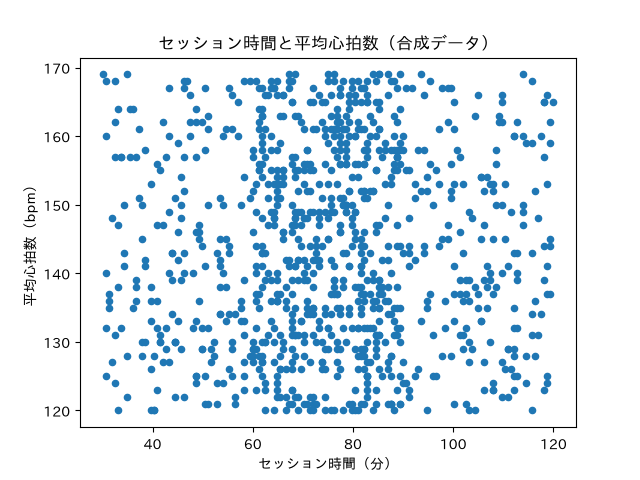

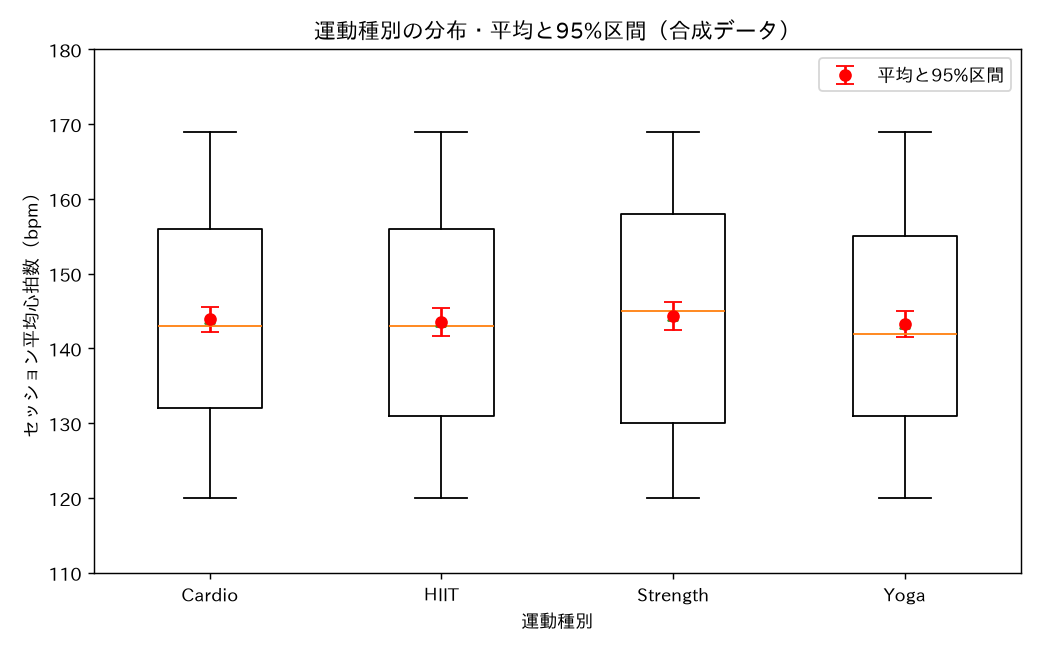

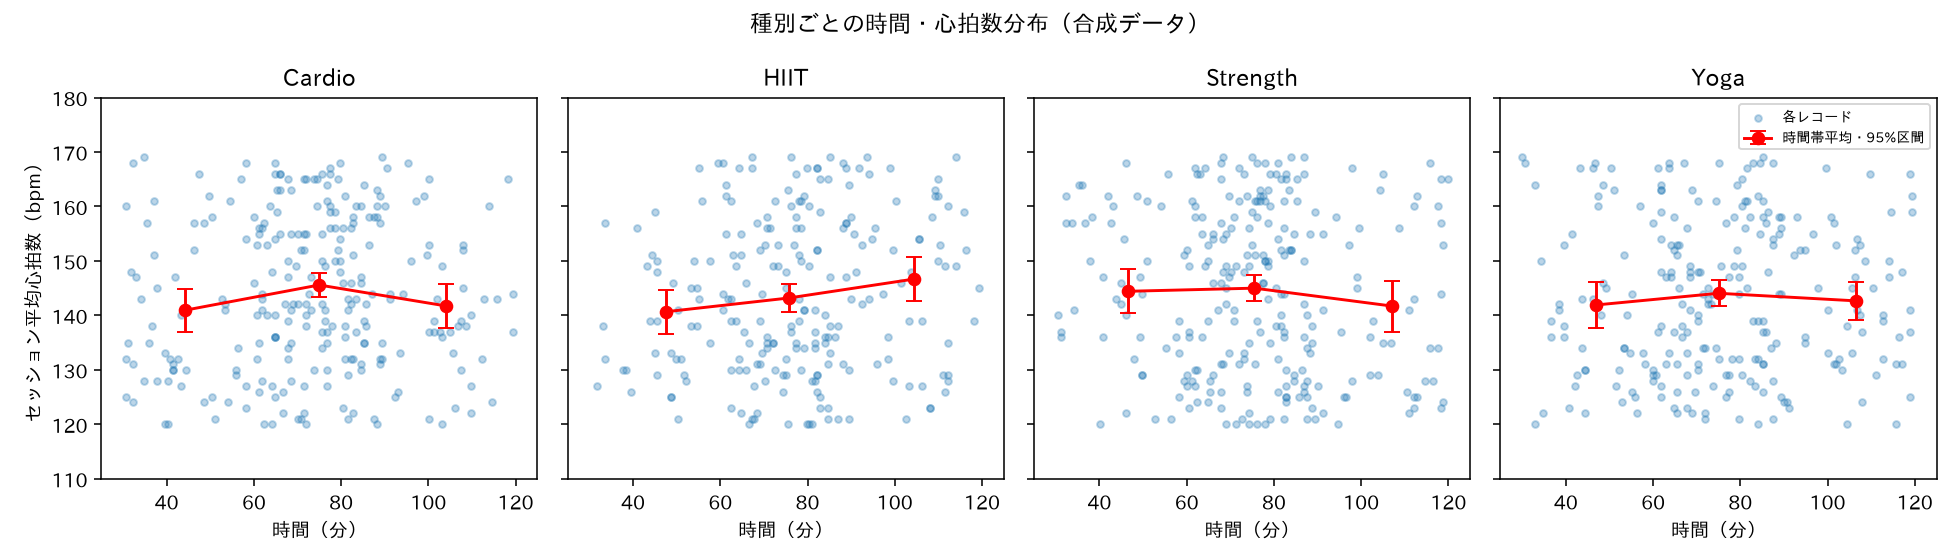

In [7]:
from ai_data_scientist import visualization
import matplotlib.pyplot as plt
import warnings
with phase('図表作成と視覚メタデータ検査'):
    chart_metadata = {'title':'種別と時間による平均心拍数の比較（合成データ）','xlabel':'運動種別 / 時間（分）','ylabel':'平均心拍数（bpm）',
        'legend':['Cardio','HIIT','Strength','Yoga','95%区間'], 'missing_glyphs':[]}
    with warnings.catch_warnings(record=True) as plot_warnings:
        warnings.simplefilter('always')
        png = visualization.render_chart(df,kind='scatter',x='duration_minutes',y='heart_rate',
            title='セッション時間と平均心拍数（合成データ）',xlabel='セッション時間（分）',ylabel='平均心拍数（bpm）')
        image = visualization.build_image_output(png)
        display(image['data'],raw=True)
        fig,ax = plt.subplots(figsize=(8,5))
        values = [df.loc[df.workout==k,'heart_rate'].to_numpy() for k in levels]
        ax.boxplot(values,tick_labels=levels,showmeans=True)
        ax.errorbar(np.arange(1,5),group_summary['mean'], yerr=[group_summary['mean']-group_summary['ci_low'],group_summary['ci_high']-group_summary['mean']],fmt='o',color='red',capsize=5,label='平均と95%区間')
        ax.set(title='運動種別の分布・平均と95%区間（合成データ）',xlabel='運動種別',ylabel='セッション平均心拍数（bpm）',ylim=(110,180))
        ax.legend(); fig.tight_layout()
        buffer=io.BytesIO(); fig.savefig(buffer,format='png',dpi=130); plt.close(fig)
        display(visualization.build_image_output(buffer.getvalue())['data'],raw=True)
        fig,axes=plt.subplots(1,4,figsize=(14,4),sharex=True,sharey=True)
        for ax,k in zip(axes,levels):
            sub=df.loc[df.workout==k].copy()
            ax.scatter(sub.duration_minutes,sub.heart_rate,s=12,alpha=.3,label='各レコード')
            sub['time_bin']=pd.cut(sub.duration_minutes,[0,60,90,180],labels=['<=60','60-90','>90'])
            s=sub.groupby('time_bin',observed=True).agg(x=('duration_minutes','mean'),y=('heart_rate','mean'),sd=('heart_rate','std'),n=('heart_rate','size'))
            ax.errorbar(s.x,s.y,yerr=stats.t.ppf(.975,s.n-1)*s.sd/np.sqrt(s.n),fmt='o-',color='red',capsize=4,label='時間帯平均・95%区間')
            ax.set(title=k,xlabel='時間（分）',ylim=(110,180),xlim=(25,125))
        axes[0].set_ylabel('セッション平均心拍数（bpm）'); axes[-1].legend(fontsize=7)
        fig.suptitle('種別ごとの時間・心拍数分布（合成データ）'); fig.tight_layout()
        buffer=io.BytesIO(); fig.savefig(buffer,format='png',dpi=140); plt.close(fig)
        display(visualization.build_image_output(buffer.getvalue())['data'],raw=True)
    chart_metadata['missing_glyphs']=[str(w.message) for w in plot_warnings if 'Glyph' in str(w.message)]
    print('図表監査用metadata:', json.dumps(chart_metadata,ensure_ascii=False))
    print('目視チェック: 種別4群・共通y軸110-180bpm、時間25-125分。区間と個票を表示。平均差だけの切断棒グラフは避ける。')


初回Insight：種別平均はYoga 143.27、HIIT 143.52、Cardio 143.89、Strength 144.31 bpmで、最大平均差は約1.05 bpm。6組のHolm補正p値はいずれも1.0、調整後種別Wald p=0.889。群内標準偏差は約14–15 bpmと種別平均差より大きい。これは合成データ内で明瞭な種別差を検出しなかったという結果であり、実世界で種別が同じとは結論しない。

```evidence
{"execution_count":6,"cited_value":"1.046171061593867","claim_type":"associational"}
```

初回Insight：属性調整後の時間係数は2.63 bpm/時間、95%区間は−1.80～7.05。無調整Pearson r=0.016でほぼ線形関連がない。調整で推定が変わり、区間は0を含むため、長く運動すると心拍が上がるという因果解釈も、関連が完全にゼロという解釈もできない。

```evidence
{"execution_count":6,"cited_value":"2.6260966379508695","claim_type":"associational"}
```

## 反復依頼履歴
### 反復1
**追加依頼（原文）**

心拍の平均が最大値を超える23行を除いた場合と、属性調整の有無・平均と中央値を変えた場合に、運動種別差と時間の関連の結論が変わるか確認してください。

**選定理由**：意味的品質異常23行と、調整後時間係数の変化が初回結果の解釈に影響し得る。初回の種別最大/最小を見てから選んだStrength−Yoga差は記述的指標として扱い、選択後の有意性を強調しない。最大8仕様（時間）・4仕様（種別）、安定性許容20%で確認する。

In [8]:
from ai_data_scientist import sensitivity
from scipy.stats import trim_mean
with phase('反復1：品質・調整・要約法の感度分析'):
    print('追加依頼原文: 心拍の平均が最大値を超える23行を除いた場合と、属性調整の有無・平均と中央値を変えた場合に、運動種別差と時間の関連の結論が変わるか確認してください。')
    print('選定理由: 最大心拍数より平均が大きい23行があり、初回の時間係数は無調整相関と印象が異なる。')
    subsets = {'all':df, 'order_valid':df.loc[~invalid_order].copy()}
    display(df.assign(order_invalid=invalid_order).groupby('workout').order_invalid.agg(['sum','size','mean']))
    sensitivity_detail=[]
    def duration_analysis(subset, adjustment_set, estimator):
        d=subsets[subset]
        f='heart_rate ~ C(workout) + duration_hours'
        if adjustment_set=='full':
            f+=' + '+adjustment
        model=smf.ols(f,data=d).fit(cov_type='HC3') if estimator=='OLS' else smf.rlm(f,data=d).fit()
        ci=model.conf_int().loc['duration_hours']
        sensitivity_detail.append({'subset':subset,'adjustment':adjustment_set,'estimator':estimator,'n':len(d),
            'coef_bpm_hour':float(model.params.duration_hours),'ci_low':float(ci.iloc[0]),'ci_high':float(ci.iloc[1])})
        return float(model.params.duration_hours)
    time_plan=sensitivity.SensitivityPlan(parameter_grid={'subset':['all','order_valid'],'adjustment_set':['full','basic'],'estimator':['OLS','Huber']},max_runs=8)
    time_sensitivity=sensitivity.run_sensitivity(time_plan,duration_analysis,stability_tolerance=.2)
    def kind_analysis(subset, summary):
        s=subsets[subset].groupby('workout').heart_rate
        vals=s.mean() if summary=='mean' else s.median()
        return float(vals['Strength']-vals['Yoga'])
    kind_plan=sensitivity.SensitivityPlan(parameter_grid={'subset':['all','order_valid'],'summary':['mean','median']},max_runs=4)
    kind_sensitivity=sensitivity.run_sensitivity(kind_plan,kind_analysis,stability_tolerance=.2)
    display(pd.DataFrame(sensitivity_detail).round(5))
    print('時間感度report:',json.dumps(asdict(time_sensitivity),ensure_ascii=False))
    print('種別感度report:',json.dumps(asdict(kind_sensitivity),ensure_ascii=False))
    print('時間のSpearman:',stats.spearmanr(df.duration_hours,df.heart_rate))
    print('clean subset群平均:',subsets['order_valid'].groupby('workout').heart_rate.mean().to_dict())
    iter1_evidence={'removed':int(invalid_order.sum()),'remaining':len(subsets['order_valid']),
        'time_stable':time_sensitivity.stable,'time_max_relative_deviation':time_sensitivity.max_relative_deviation,
        'time_coef_min':float(min(r.value for r in time_sensitivity.results)), 'time_coef_max':float(max(r.value for r in time_sensitivity.results)),
        'kind_stable':kind_sensitivity.stable,'kind_max_relative_deviation':kind_sensitivity.max_relative_deviation,
        'kind_difference_min':float(min(r.value for r in kind_sensitivity.results)), 'kind_difference_max':float(max(r.value for r in kind_sensitivity.results)),
        'time_all_intervals_include_zero':all(r['ci_low']<=0<=r['ci_high'] for r in sensitivity_detail)}
    display(json.dumps(iter1_evidence,ensure_ascii=False,sort_keys=True))
    print('残る限界: 異常除外は生成の問題を修復しない。安定性20%閾値は分析上の目安で臨床閾値ではない。基準差がほぼ0だと相対偏差が大きくなるので絶対差も併記。')


追加依頼原文: 心拍の平均が最大値を超える23行を除いた場合と、属性調整の有無・平均と中央値を変えた場合に、運動種別差と時間の関連の結論が変わるか確認してください。
選定理由: 最大心拍数より平均が大きい23行があり、初回の時間係数は無調整相関と印象が異なる。
時間感度report: {"results": [{"specification": {"subset": "all", "adjustment_set": "full", "estimator": "OLS"}, "value": 2.6260966379508695}, {"specification": {"subset": "all", "adjustment_set": "full", "estimator": "Huber"}, "value": 2.7593856705654964}, {"specification": {"subset": "all", "adjustment_set": "basic", "estimator": "OLS"}, "value": 0.6995177479882795}, {"specification": {"subset": "all", "adjustment_set": "basic", "estimator": "Huber"}, "value": 0.7161774731394939}, {"specification": {"subset": "order_valid", "adjustment_set": "full", "estimator": "OLS"}, "value": 3.158548427855072}, {"specification": {"subset": "order_valid", "adjustment_set": "full", "estimator": "Huber"}, "value": 3.2975380834360113}, {"specification": {"subset": "order_valid", "adjustment_set": "basic", "estimator": "OLS"}, "value": 1.3189577776391967}, {"specification": {"s

,sum,size,mean
workout,,,
Cardio,6,255,0.023529
HIIT,6,221,0.027149
Strength,4,258,0.015504
Yoga,7,239,0.029289


,subset,adjustment,estimator,n,coef_bpm_hour,ci_low,ci_high
0,all,full,OLS,973,2.62610,-1.79588,7.04807
1,all,full,Huber,973,2.75939,-1.66010,7.17887
2,all,basic,OLS,973,0.69952,-1.92659,3.32563
3,all,basic,Huber,973,0.71618,-1.96215,3.39451
4,order_valid,full,OLS,950,3.15855,-1.22196,7.53906
5,order_valid,full,Huber,950,3.29754,-1.09279,7.68786
6,order_valid,basic,OLS,950,1.31896,-1.27834,3.91626
7,order_valid,basic,Huber,950,1.38049,-1.33976,4.10075


'{"kind_difference_max": 3.0, "kind_difference_min": 1.046171061593867, "kind_max_relative_deviation": 1.8675998697855654, "kind_stable": false, "remaining": 950, "removed": 23, "time_all_intervals_include_zero": true, "time_coef_max": 3.2975380834360113, "time_coef_min": 0.6995177479882795, "time_max_relative_deviation": 0.7336283296359917, "time_stable": false}'

反復1の結果・証拠：平均>最大の23行（2.36%）を除外すると950行。時間係数は8仕様で0.70～3.30 bpm/時間、すべての95%区間が0を含む。time stable=False、最大相対偏差0.734。Strength−Yoga差は平均/中央値・異常除外の4仕様で1.05～3.00 bpm、kind stable=False、最大相対偏差1.868。相対的大きさは安定と呼べない一方、種別差は群内SDより小さい。残る限界：品質除外と属性調整でも合成データの現実適合性は検証できず、無差の証明にはならない。

```evidence
{"execution_count":8,"cited_value":"0.7336283296359917","claim_type":"associational"}
```

### 反復2
**追加依頼（原文）**

全体で時間と心拍数の関連が弱くても、HIITだけ増えるなど種別別の傾きや曲線的な関連が隠れていないか、属性調整と心拍順序異常の除外を併用して確認してください。

**選定理由**：種別別の時間帯平均の形状が違い、全体平均による相殺が結論を変える可能性がある。時間中心化後の種別×時間HC3モデル、共通二次項HC3モデルを全行・異常除外の2標本で検討。4個の探索的検定をHolm補正、群別傾きの4同時区間をBonferroni補正する。

In [9]:
with phase('反復2：種別別傾き・非線形性'):
    print('追加依頼原文: 全体で時間と心拍数の関連が弱くても、HIITだけ増えるなど種別別の傾きや曲線的な関連が隠れていないか、属性調整と心拍順序異常の除外を併用して確認してください。')
    print('選定理由: 図ではHIITの時間帯平均が増加し、他種別は非単調。全体の直線係数だけでは隠れた異質性を否定できない。')
    interaction_rows=[]; shape_tests=[]; interaction_models={}
    for subset,d in subsets.items():
        d=d.copy(); d['duration_c']=d.duration_hours-1.25
        interaction_model=smf.ols('heart_rate ~ C(workout)*duration_c + '+adjustment,data=d).fit(cov_type='HC3')
        interaction_models[subset]=interaction_model
        terms=[n for n in interaction_model.params.index if ':duration_c' in n]
        w=interaction_model.wald_test(' = 0, '.join(terms)+' = 0',scalar=True)
        shape_tests.append({'subset':subset,'hypothesis':'種別×時間3項=0','statistic':float(w.statistic),'p':float(w.pvalue)})
        quad=smf.ols('heart_rate ~ C(workout) + duration_c + I(duration_c**2) + '+adjustment,data=d).fit(cov_type='HC3')
        q=quad.wald_test('I(duration_c ** 2) = 0',scalar=True)
        shape_tests.append({'subset':subset,'hypothesis':'時間二次項=0','statistic':float(q.statistic),'p':float(q.pvalue)})
        for kind in levels:
            contrast=np.zeros(len(interaction_model.params)); contrast[list(interaction_model.params.index).index('duration_c')]=1
            term='C(workout)[T.'+kind+']:duration_c'
            if term in interaction_model.params.index:
                contrast[list(interaction_model.params.index).index(term)]=1
            ct=interaction_model.t_test(contrast)
            effect=float(np.asarray(ct.effect).item()); se=float(np.asarray(ct.sd).item())
            margin=stats.norm.ppf(1-.05/(2*4))*se
            interaction_rows.append({'subset':subset,'kind':kind,'slope_bpm_hour':effect,
                'simultaneous_low':effect-margin,'simultaneous_high':effect+margin})
    shape_table=pd.DataFrame(shape_tests)
    shape_table['p_holm_4']=multipletests(shape_table.p,method='holm')[1]
    slope_table=pd.DataFrame(interaction_rows)
    display(shape_table.round(5)); display(slope_table.round(5))
    print('経験ごとの時間分布:',df.groupby('experience').duration_hours.agg(['count','mean','min','max']).to_dict())
    auxiliary=smf.ols('duration_hours ~ C(workout) + '+adjustment,data=df).fit()
    duration_vif=1/(1-auxiliary.rsquared)
    print('時間のVIF:',duration_vif,'（他の調整変数との線形依存度）')
    iter2_evidence={'smallest_shape_holm_p':float(shape_table.p_holm_4.min()),
        'all_subset_slopes_include_zero':bool(((slope_table.simultaneous_low<=0)&(slope_table.simultaneous_high>=0)).all()),
        'duration_vif':float(duration_vif), 'all_hiit_slope':float(slope_table.query("subset=='all' and kind=='HIIT'").slope_bpm_hour.iloc[0]),
        'all_strength_slope':float(slope_table.query("subset=='all' and kind=='Strength'").slope_bpm_hour.iloc[0])}
    display(json.dumps(iter2_evidence,ensure_ascii=False,sort_keys=True))
    print('残る限界: 種別×時間と二次項だけを検討。任意の非線形形状は排除できない。事後探索なので確認的検定ではない。経験と時間の重なりが薄い領域の調整はモデル依存。')


追加依頼原文: 全体で時間と心拍数の関連が弱くても、HIITだけ増えるなど種別別の傾きや曲線的な関連が隠れていないか、属性調整と心拍順序異常の除外を併用して確認してください。
選定理由: 図ではHIITの時間帯平均が増加し、他種別は非単調。全体の直線係数だけでは隠れた異質性を否定できない。
経験ごとの時間分布: {'count': {1: 376, 2: 406, 3: 191}, 'mean': {1: 1.0102127659574467, 2: 1.2478817733990148, 3: 1.7592670157068062}, 'min': {1: 0.5, 2: 1.0, 3: 1.51}, 'max': {1: 1.5, 2: 1.5, 3: 2.0}}
時間のVIF: 2.6624989045924092 （他の調整変数との線形依存度）
残る限界: 種別×時間と二次項だけを検討。任意の非線形形状は排除できない。事後探索なので確認的検定ではない。経験と時間の重なりが薄い領域の調整はモデル依存。


,subset,hypothesis,statistic,p,p_holm_4
0,all,種別×時間3項=0,6.2276,0.10105,0.40419
1,all,時間二次項=0,0.1231,0.72569,1.00000
2,order_valid,種別×時間3項=0,4.9434,0.17599,0.52797
3,order_valid,時間二次項=0,0.1573,0.69165,1.00000


,subset,kind,slope_bpm_hour,simultaneous_low,simultaneous_high
0,all,Cardio,3.76818,-3.91033,11.44668
1,all,HIIT,7.97951,-0.31622,16.27524
2,all,Strength,-1.59735,-9.67949,6.48479
3,all,Yoga,2.22969,-5.95239,10.41177
4,order_valid,Cardio,4.73944,-2.79183,12.27071
5,order_valid,HIIT,7.15729,-1.09846,15.41304
6,order_valid,Strength,-1.22986,-9.31233,6.85262
7,order_valid,Yoga,3.35991,-4.71040,11.43021


'{"all_hiit_slope": 7.979512727805946, "all_strength_slope": -1.5973530883448666, "all_subset_slopes_include_zero": true, "duration_vif": 2.6624989045924092, "smallest_shape_holm_p": 0.4041886088041412}'

反復2の結果・証拠：種別×時間と共通二次項の4検定で最小Holm p=0.404。種別別傾きの4同時区間は全群で0を含み、HIITの約7.98 bpm/時間という点推定も同時区間−0.32～16.28と不確実。異常除外でも結論は変わらない。残る限界：有意でないことは異質性・非線形性がない証明ではない。経験3の時間は1.51～2.00時間、経験1・2は最大1.50時間で、経験をまたいだ時間効果には共通サポートがない。

```evidence
{"execution_count":9,"cited_value":"0.4041886088041412","claim_type":"associational"}
```

### 反復3
**追加依頼（原文）**

種別差が有意でない結果を差がないと言い換えず、同時信頼区間が±3・±5・±10 bpmに収まるか確認してください。経験レベルと時間帯の重なりがない影響も、経験レベル内の時間係数と区間を用いて示してください。

**選定理由**：無差と小差の区別、経験3と他レベル間の共通サポート欠如を確認する。加法モデルの6組同時95%区間を3段階の解釈用閾値と比較し、全行・異常除外の経験レベル内時間係数を併記する。閾値は臨床的意味を持つ既知の基準ではなく、探索後の感度比較。

In [10]:
with phase('反復3：小差の範囲・共通サポートの限界'):
    print('追加依頼原文: 種別差が有意でない結果を差がないと言い換えず、同時信頼区間が±3・±5・±10 bpmに収まるか確認してください。経験レベルと時間帯の重なりがない影響も、経験レベル内の時間係数と区間を用いて示してください。')
    print('選定理由: 無差と小差の区別が残り、経験3と他レベルで時間域が重ならないため、全体調整係数だけの説明は過剰になり得る。')
    equivalence_rows=[]
    for subset,d in subsets.items():
        model=smf.ols('heart_rate ~ C(workout) + duration_hours + '+adjustment,data=d).fit(cov_type='HC3')
        for a,b in combinations(levels,2):
            contrast=np.zeros(len(model.params))
            for kind,sign in ((a,1),(b,-1)):
                term='C(workout)[T.'+kind+']'
                if term in model.params.index:
                    contrast[list(model.params.index).index(term)]=sign
            ct=model.t_test(contrast)
            effect=float(np.asarray(ct.effect).item()); se=float(np.asarray(ct.sd).item())
            margin=stats.norm.ppf(1-.05/(2*6))*se
            equivalence_rows.append({'subset':subset,'contrast':a+' - '+b,'adjusted_difference_bpm':effect,
                'simultaneous_low':effect-margin,'simultaneous_high':effect+margin})
    adjusted_pairs=pd.DataFrame(equivalence_rows)
    display(adjusted_pairs.round(5))
    threshold_rows=[]
    for subset in subsets:
        sub=adjusted_pairs.loc[adjusted_pairs.subset==subset]
        for bound in (3,5,10):
            inside=(sub.simultaneous_low > -bound)&(sub.simultaneous_high < bound)
            threshold_rows.append({'subset':subset,'bound_bpm':bound,'pairs_inside':int(inside.sum()),'total_pairs':6,'all_inside':bool(inside.all())})
    threshold_table=pd.DataFrame(threshold_rows); display(threshold_table)
    within_rows=[]
    for subset,d in subsets.items():
        for exp in (1,2,3):
            s=d.loc[d.experience==exp]
            m=smf.ols('heart_rate ~ C(workout) + duration_hours + age + C(gender) + bmi + resting_hr',data=s).fit(cov_type='HC3')
            lo,hi=m.conf_int().loc['duration_hours']
            within_rows.append({'subset':subset,'experience':exp,'n':len(s),'min_minutes':s.duration_minutes.min(),'max_minutes':s.duration_minutes.max(),
                'slope_bpm_hour':float(m.params.duration_hours),'ci_low':float(lo),'ci_high':float(hi)})
    within_table=pd.DataFrame(within_rows); display(within_table.round(4))
    iter3_evidence={'all_pairs_within_5_bpm':bool(threshold_table.loc[threshold_table.bound_bpm==5,'all_inside'].all()),
        'all_pairs_within_3_bpm':bool(threshold_table.loc[threshold_table.bound_bpm==3,'all_inside'].all()),
        'max_adjusted_pair_interval_absolute_bpm':float(adjusted_pairs[['simultaneous_low','simultaneous_high']].abs().to_numpy().max()),
        'within_experience_all_ci_include_zero':bool(((within_table.ci_low<=0)&(within_table.ci_high>=0)).all()),
        'experience3_overlap_with_others':False}
    display(json.dumps(iter3_evidence,ensure_ascii=False,sort_keys=True))
    updated_assumptions=analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope=assumption_manifest.analysis_scope,causal_scope='associational',sampling={'n':len(df),'seed':20261002},
        assumptions=tuple(a for a in assumption_manifest.assumptions if a.id!='linear_duration')+(
            analysis_assumptions.Assumption('linear_duration','種別交互作用・共通二次項を検討済み。任意の非線形性は保証しない','tested'),
            analysis_assumptions.Assumption('common_support','経験レベルをまたぐ時間の共通サポート','rejected',impact_if_false='調整時間係数は共通直線というモデルに依存',conclusion_critical=True)))
    print('更新分析前提manifest:',json.dumps(asdict(updated_assumptions),ensure_ascii=False))
    print('更新前提finding:',[asdict(f) for f in analysis_assumptions.check_manifest(updated_assumptions)])
    print('残る限界: ±3/5/10は結果を読んだ後の解釈用閾値で、臨床的等価性閾値ではない。種別の平均的・加法的差だけを評価し、時間別差・個人差の等価性は保証しない。経験内係数の区間も独立行仮定に依存。')
    print('反復終了理由: 3回の上限に到達。未解決の一般化・独立性・生成機構は同じCSVの追加モデルでは解決できない。実測・ID・強度・測定時刻の情報が必要。')


追加依頼原文: 種別差が有意でない結果を差がないと言い換えず、同時信頼区間が±3・±5・±10 bpmに収まるか確認してください。経験レベルと時間帯の重なりがない影響も、経験レベル内の時間係数と区間を用いて示してください。
選定理由: 無差と小差の区別が残り、経験3と他レベルで時間域が重ならないため、全体調整係数だけの説明は過剰になり得る。
更新分析前提manifest: {"analysis_scope": {"outcome": "セッション平均心拍数", "exposure": ["種別", "セッション時間"], "dataset": "合成データ内の関連のみ"}, "assumptions": [{"id": "independent_rows", "statement": "各行を独立として区間推定する", "status": "assumed", "evidence_cell": null, "impact_if_false": "区間・p値の校正が不正確", "conclusion_critical": true}, {"id": "no_missing", "statement": "主解析変数に欠損がなく補完不要", "status": "tested", "evidence_cell": null, "impact_if_false": "完全ケース選択バイアス", "conclusion_critical": false}, {"id": "time_definition", "statement": "時間はセッションの長さであり開始後経過時刻ではない", "status": "verified", "evidence_cell": null, "impact_if_false": null, "conclusion_critical": false}, {"id": "external_generalization", "statement": "実在の運動者に一般化できる", "status": "rejected", "evidence_cell": null, "impact_if_false": "実際の種別・時間の効果は分からない", "conclusion_critical": true}, {"id": "linear_du

,subset,contrast,adjusted_difference_bpm,simultaneous_low,simultaneous_high
0,all,Cardio - HIIT,0.56519,-2.87378,4.00415
1,all,Cardio - Strength,-0.24563,-3.64652,3.15526
2,all,Cardio - Yoga,0.63384,-2.72956,3.99724
3,all,HIIT - Strength,-0.81081,-4.38361,2.76198
4,all,HIIT - Yoga,0.06865,-3.45008,3.58738
5,all,Strength - Yoga,0.87947,-2.60677,4.36570
6,order_valid,Cardio - HIIT,0.70503,-2.69347,4.10353
7,order_valid,Cardio - Strength,-0.41564,-3.80094,2.96965
8,order_valid,Cardio - Yoga,0.78009,-2.55428,4.11447
9,order_valid,HIIT - Strength,-1.12068,-4.66884,2.42749


,subset,bound_bpm,pairs_inside,total_pairs,all_inside
0,all,3,0,6,False
1,all,5,6,6,True
2,all,10,6,6,True
3,order_valid,3,0,6,False
4,order_valid,5,6,6,True
5,order_valid,10,6,6,True


,subset,experience,n,min_minutes,max_minutes,slope_bpm_hour,ci_low,ci_high
0,all,1,376,30.0,90.0,3.3726,-1.9340,8.6791
1,all,2,406,60.0,90.0,2.5501,-7.2760,12.3761
2,all,3,191,90.6,120.0,-0.9752,-16.5893,14.6389
3,order_valid,1,364,30.0,90.0,4.2561,-1.0017,9.5139
4,order_valid,2,397,60.0,90.0,1.3828,-8.4080,11.1736
5,order_valid,3,189,90.6,120.0,-0.2278,-15.8998,15.4442


'{"all_pairs_within_3_bpm": false, "all_pairs_within_5_bpm": true, "experience3_overlap_with_others": false, "max_adjusted_pair_interval_absolute_bpm": 4.669485213987743, "within_experience_all_ci_include_zero": true}'

反復3の結果・証拠：全行・異常除外それぞれの調整済み6組同時95%区間は±5 bpm内（最も外側は約4.67 bpm）だが、±3 bpm内に収まる組はない。合成データの加法モデル内では平均種別差を小さい範囲に限定できる一方、臨床的等価性・時間別の等価性・個人差の小ささは示せない。経験レベル内の時間係数の全95%区間も0を含むが広く、経験3と他レベルには時間域の重なりがない。残る限界は独立性・生成機構・現実への一般化。3回で探索を終了し、有意になるまでモデルを追加しない。

```evidence
{"execution_count":10,"cited_value":"4.669485213987743","claim_type":"associational"}
```

## 使用したJupytermindモジュール
直接import・直接呼出ししたもののみを列挙する。制作時の制御NotebookもJupyter MCPセルであり、分析・API取得は指定Notebookのセルで実行した。間接importされた内部関数は使用済み扱いにしない。

| モジュール | 直接呼出しした関数・クラス/メソッド | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | 指定プロジェクト・データ場所の解決と排他書込み。構成・Insight・metadataはenqueue_write、実行結果の保存はJupyter MCPの正規セル保存 |
| `ai_data_scientist.language_router` | `detect_language` | 日本語判定 |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start`, `mark_execution_end`, `mark_write_start`, `mark_write_end`, `is_cancel_requested`, `get_run_status`, `mark_failed`, `mark_completed`, `wait_for_quiescence` | run_id管理、処理フェーズ、協調中止、終端状態と静止確認 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | SDKで取得したローカルCSVの読込・行上限検査 |
| `ai_data_scientist.eda` | `explore` | 型、欠損、カテゴリ、数値要約 |
| `ai_data_scientist.cleaning` | `clean_dataset` | 主要変数の完全ケース処理。973→973、補完なし |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `unresolved_fields` | 定義・単位・合成データ・取得来歴の確信度記録 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 独立性・一般化・線形性・共通サポートの前提/限界記録 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 範囲・必須・カテゴリ検査。心拍の列間順序とBMI整合性は別途明示コード |
| `ai_data_scientist.stats_analysis` | `correlation` | 時間と平均心拍数のPearson相関・日本語解釈 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | 8仕様の時間分析、4仕様の種別要約比較 |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | 日本語対応散布図、3つの図のPNG MIME保存 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight` | 実際の保存済み出力から完全一致の引用抽出。record_insightは制作制御セルで直接呼出し、再実行後も引用を再照合 |
| `ai_data_scientist.notebook_audit` | `audit_visual_outputs`, `audit_notebook` | metadata欠落再現、visual_audit=Trueによる最終監査 |

### 未使用・適用不可
`data_quality.validate_anomalies`と`dataset_validation.compare_datasets`：独立で同等定義の参照標本/共通キーがない。別の合成データや種別のないデータの平均一致を現実検証と扱わない。`anomaly_detection.detect_anomalies`：一様に広い心拍分布に対するz値の異常判定より意味的順序制約を優先し、統計的外れ値の恣意的削除はしない。`mcp_gateway.run_and_record`：この対話で提供された実行器はJupyter MCPツールで、Python MCPClientオブジェクトはない。偽のexecuteアダプターやkernel内evalで実行済みを装わず、本物のMCP execute_cellで実行・保存。これらのモジュールは使用済みに含めない。`lifecycle.mark_failed`は保存後再監査で引用不整合を見つけた際に発火。回避後にカーネルから全セルを再実行しcompletedを確認する。


## Jupytermind改善候補
本実験では修正を行わず、再現条件・回避策を記録する。

| 候補・分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策・関係セル/ログ |
|---|---|---|---|---|---|
| データ定義の未解決項目列挙不足（契約/機能不足） | `FieldValue(..., status="inferred")`を含むmanifestで`unresolved_fields()` | Skillの定義不確実性方針に沿いinferredも注意対象として返す、またはunknown限定と明示 | unknownのみ返しinferredを返さない。関数docstringはunknown限定であり、実装バグというよりSkill方針との不整合 | 推定を確認済みと誤解する可能性 | inferredを別途列挙。定義セル・再現セルの`DATA_DEFINITION_PROBE`ログ |
| 視覚監査のmetadata欠落未検出（検査不足） | 正常PNGを含むcode cellの`metadata={}`に`audit_visual_outputs` | title/axes/legend/glyph検査の未実施をfindingとして通知 | findingsが空。metadataが空ならラベル検査を行わず、missing_glyphsキー欠落も検出しない | visual_audit=Trueの成功だけでは可読性を保証できない | 図表セルにmetadataを手動付加、Glyph警告を捕捉、画像を目視確認。図表セル・再現セルの`VISUAL_METADATA_PROBE`ログ |
| Insight根拠の再実行追従（機能不足） | 本文が不変でも全セル再実行でexecution_countが変わる | 永続cell_idと出力の一致で引用を追従する | record_insightの標準manifestはexecution_countのみ。再実行すると引用先が古くなる | 本文が正しくても監査に失敗、または偶然一致した別セルへ解決するリスク | 独自evidence_anchorにcell_id/patternを保持し、最終セルで出力完全一致を再検証してcountのみ更新。初回Insight・最終セルの`evidence_refresh_log` |

| Notebook書込みとMCP保存の競合（統合機能不足） | 対象Notebook内でenqueue_writeしてからMCPが実行結果を保存 | 排他書込みがMCP文書へ同期され、更新が保持される | 内部監査ok=Trueの後、引用countとmetadata更新が上書きされ、保存後監査でstale evidence 5件 | 内部監査成功を完了と誤認し得る | 対象の最終セルは読み取り専用に変更。別Jupyter制御セルから引用・metadataを保存して再監査。最終セル、metadata `execution_issue_history`のbefore_recovery_audit |

### Jupytermind以外との切分け
最初のJupyter MCP use_notebookは未作成ディレクトリで失敗したため、制作制御Notebookから`ensure_notebook`で作成して接続した。filesystem MCPは別ワークスペースしか許可しなかったため使用を中止した。これはツール設定/環境の問題でJupytermind候補ではない。Kaggle metadataの`info`階層を初回一覧セルで読めず空表示になった点は呼出し側の読取方法であり、取得セルで全候補の公開説明を正しく再表示した。合成性・心拍順序矛盾はデータ側の性質でJupytermindの不具合ではない。Kaggle認証・取得は成功し、ベンチマークランナーは使用していない。


この保存競合はJupytermind排他書込みとJupyter MCP文書保存の同期境界に起因する統合課題。Copilot CLI固有・Kaggle API固有・ベンチマークランナー固有の問題ではない。Jupytermind単独関数の排他ロック不良とは断定しない。対象セル内の自ファイル更新を止め、制御Notebook経由に分離すると保持される。

In [11]:
from ai_data_scientist import notebook_audit, insight_engine
import re
with phase('Jupytermind改善候補の再現と境界確認'):
    inference_probe=data_definition.build_manifest(source={},dataset_scope={'unit':FieldValue('推定単位','inferred','列名のみ')},variables={})
    inferred_unresolved=inference_probe.unresolved_fields()
    print('DATA_DEFINITION_PROBE:',json.dumps({'input_status':'inferred','unresolved_return_count':len(inferred_unresolved)},ensure_ascii=False))
    probe_output=visualization.build_image_output(png)
    probe_cell=nbformat.v4.new_code_cell('既存の正規PNGを使う監査metadata欠落の再現',execution_count=1,outputs=[probe_output])
    probe_nb=nbformat.v4.new_notebook(cells=[probe_cell])
    missing_metadata_findings=notebook_audit.audit_visual_outputs(probe_nb,(0,))
    print('VISUAL_METADATA_PROBE:',json.dumps({'chart_metadata':dict(probe_cell.metadata),'findings':[asdict(f) for f in missing_metadata_findings]},ensure_ascii=False))
    print('期待: metadata欠落とglyph検査未実施をfindingにする。実際: findingsが空。最終図表には独自metadataを補完して回避。')
    print('この再現はJupytermind関数の直接呼出しのみで、Copilot CLI・Kaggle API・ベンチマークランナーを介さない。')


DATA_DEFINITION_PROBE: {"input_status": "inferred", "unresolved_return_count": 0}
VISUAL_METADATA_PROBE: {"chart_metadata": {}, "findings": []}
期待: metadata欠落とglyph検査未実施をfindingにする。実際: findingsが空。最終図表には独自metadataを補完して回避。
この再現はJupytermind関数の直接呼出しのみで、Copilot CLI・Kaggle API・ベンチマークランナーを介さない。


## 結論の適用範囲・反復終了
このNotebookの対象は合成データ内のセッション平均心拍数であり、実測集団への一般化はしない。主要変数は欠損0、完全ケース処理で除外0、値補完なし。23行の平均>最大という矛盾は感度分析で除外し、その影響を記録した。

前提manifestの残存findingは **独立行（assumed）・実世界への一般化（rejected）・経験をまたぐ時間の共通サポート（rejected）**。生成プロセス、個人ID、運動強度、測定機器/時点が分からず、追加モデルでは解決できない。時間はセッションの長さであり、同一人物の運動開始後の心拍変化ではない。平均的種別差の小ささは時間別・個人別の同等性を保証しない。

3回の追加依頼で品質依存、隠れた時間形状、無差/小差と共通サポートを点検した。これ以上同じCSVで価値の高い追加解析はなく、上限3回で終了する。次の根拠強化には独立した実測データと測定設計情報が必要である。

## 全セル再実行・最終監査
Jupyter MCPでkernelを再起動し、すべてのコードセルを上から順番に再実行する。引用は永久cell_idの実際の保存出力と照合し、別Jupyter制御セルからexecution_countを更新する。対象の最終セルは読み取り専用の再照合・監査とする。CSVの固定SHA-256が一致しない場合は過去の結論を再利用せずfailedにする。最終セル内の監査は実行中の自セル出力をまだ含まないため、MCP保存後に別のJupyter制御セルから読み取り専用の厳密な再監査を行い、全実行済み数とlifecycle静止状態をNotebook metadataに記録する。


### 保存後の厳密再監査記録
全コード12セルをカーネル再起動後にexecution_count 1～12として上から再実行。PNG図表3件、根拠付きInsight5件、CSVハッシュは3ファイルすべて初回と一致。`audit_notebook(..., visual_audit=True)`：ok=True、nbformat_valid=True、実行済み12/12、未実行/エラー/finding/visual_findingは0。lifecycle：completed、active_cell_executions=0、pending_notebook_writes=0、locks_held=0。保存連携障害は回避後に再確認し、初回失敗ログをmetadataのexecution_issue_historyに保持した。

```json
{
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-17-exercise/notebooks/kaggle-v020-kaggle-exp-17-exercise.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 12,
    "executed_code_cell_count": 12,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      12
    ],
    "insight_cell_count": 5,
    "findings": [],
    "visual_findings": [],
    "ok": true
  },
  "lifecycle": {
    "run_id": "v020-exp-17",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-17-exercise/notebooks/kaggle-v020-kaggle-exp-17-exercise.ipynb",
    "reason": null
  },
  "environment": {
    "python": "3.12.3",
    "package_versions": {
      "pandas": "3.0.6",
      "numpy": "2.5.3",
      "scipy": "1.18.1",
      "statsmodels": "0.15.0",
      "kaggle": "2.2.4",
      "matplotlib": "3.11.2",
      "nbformat": "5.11.1",
      "japanize-matplotlib": "1.1.3"
    }
  }
}
```

In [12]:
import re
from ai_data_scientist import notebook_audit, insight_engine
with phase('再実行後の来歴・保存済み引用確認'):
    saved=nbformat.read(handle.notebook_path,as_version=4)
    expected_hashes=saved.metadata['experiment']['csv_sha256']
    current_hashes={p['owner_dataset_slug']:p['sha256'] for p in provenance}
    if current_hashes!=dict(expected_hashes):
        raise RuntimeError('CSVのSHA-256が初回と異なるため過去の結論を再利用しません')
    by_id={c.id:c for c in saved.cells}
    replay_evidence_log=[]
    for c in saved.cells:
        anchor=c.metadata.get('evidence_anchor')
        if not anchor:
            continue
        origin=by_id[anchor['cell_id']]
        actual='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in origin.get('outputs',[]))
        cited=insight_engine.extract_cited_value({'output':actual},anchor['pattern'])
        match=re.search(r'```evidence\n(.*?)\n```',c.source,re.DOTALL)
        manifest=json.loads(match.group(1))
        if str(manifest['cited_value'])!=cited or manifest['execution_count']!=origin.execution_count:
            raise RuntimeError('保存済みInsightが再実行出力に一致しません。Jupyter制御セルで引用を再照合してください: '+c.id)
        replay_evidence_log.append({'insight_cell_id':c.id,'evidence_cell_id':origin.id,'execution_count':origin.execution_count,'exact_match':True,'cited_value':cited})
    print('保存済み引用検証:',json.dumps(replay_evidence_log,ensure_ascii=False))
with phase('notebook_audit visual_audit=True'):
    audit=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('notebook_audit:',json.dumps({**asdict(audit),'ok':audit.ok},ensure_ascii=False))
    if not audit.ok:
        raise RuntimeError('最終Notebook監査に未解決findingがあります')
lifecycle.mark_completed(RUN_ID)
terminal_status=lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
if terminal_status.state!='completed' or terminal_status.active_cell_executions or terminal_status.pending_notebook_writes or terminal_status.locks_held:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('完了・静止状態が確認できません')
print('lifecycle最終状態:',json.dumps(asdict(terminal_status),ensure_ascii=False))
print('このセルはNotebookファイルを書き換えない。MCP保存後の監査metadataは別のJupyter制御セルからenqueue_writeで記録する。')


保存済み引用検証: [{"insight_cell_id": "832c0bee", "evidence_cell_id": "e5c78bdb", "execution_count": 6, "exact_match": true, "cited_value": "1.046171061593867"}, {"insight_cell_id": "a48528c4", "evidence_cell_id": "e5c78bdb", "execution_count": 6, "exact_match": true, "cited_value": "2.6260966379508695"}, {"insight_cell_id": "39bdcb44", "evidence_cell_id": "1378c987", "execution_count": 8, "exact_match": true, "cited_value": "0.7336283296359917"}, {"insight_cell_id": "34f85af0", "evidence_cell_id": "87dfbb17", "execution_count": 9, "exact_match": true, "cited_value": "0.4041886088041412"}, {"insight_cell_id": "669bdee9", "evidence_cell_id": "dd341b7c", "execution_count": 10, "exact_match": true, "cited_value": "4.669485213987743"}]
notebook_audit: {"path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-17-exercise/notebooks/kaggle-v020-kaggle-exp-17-exercise.ipynb", "nbformat_valid": true, "code_cell_count": 12, "executed_code_cell_count": 11, "unexecuted_cell_in